In [ ]:
import pandas as pd

merge_iter_root = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/'
all_metrics_info = pd.read_csv(merge_iter_root + 'all_iterations_metrics.csv')
all_merge_info = pd.read_csv(merge_iter_root + 'all_iterations_merge_info.csv')

In [ ]:
# number of merges inspected at first iteration i.e. all present merges
all_merge_info[all_merge_info.iteration == 0].groupby('ds_name').size()

ds_name
BF-C2DL-HSC_01           1
BF-C2DL-HSC_02           4
BF-C2DL-MuSC_01         34
BF-C2DL-MuSC_02         49
Fluo-C3DL-MDA231_01      1
Fluo-C3DL-MDA231_02      4
Fluo-N2DH-GOWT1_01       3
Fluo-N2DH-GOWT1_02      10
Fluo-N2DH-SIM+_01        4
Fluo-N2DH-SIM+_02        1
Fluo-N2DL-HeLa_01       15
Fluo-N2DL-HeLa_02       32
Fluo-N3DH-CE_01         15
Fluo-N3DH-CE_02         31
PhC-C2DL-PSC_01        307
PhC-C2DL-PSC_02         61
dtype: int64

In [7]:
import seaborn as sns

for column in ['fn_nodes', 'fp_edges', 'fn_edges']:
    new_col_name = f'{column}_prop'
    starting_col = all_metrics_info[all_metrics_info.iteration == 0][['ds_name', column]]
    starting_col = dict(zip(starting_col['ds_name'], starting_col[column]))
    all_metrics_info[new_col_name] = all_metrics_info.apply(lambda row: row[column] / starting_col[row['ds_name']], axis=1)

In [93]:
all_metrics_info['all_edge_errors'] = all_metrics_info['fp_edges'] + all_metrics_info['fn_edges']
starting_all_edge_error = all_metrics_info[all_metrics_info.iteration == 0][['ds_name', 'all_edge_errors']]
starting_all_edge_error = dict(zip(starting_all_edge_error['ds_name'], starting_all_edge_error['all_edge_errors']))
all_metrics_info['all_edge_errors_prop'] = all_metrics_info.apply(lambda row: row['all_edge_errors'] / starting_all_edge_error[row['ds_name']], axis=1)

In [94]:
all_metrics_info["introduced"] = (
    all_metrics_info.groupby("ds_name")["fn_nodes"]
      .diff()
      .abs()
      .fillna(0)
)
all_metrics_info['corrected_edges'] = (
    all_metrics_info.groupby("ds_name")["all_edge_errors"]
      .diff()
      .abs()
      .fillna(0)
)
all_metrics_info['corrections_per_introduced'] = all_metrics_info.corrected_edges / all_metrics_info.introduced

In [149]:
import pandas as pd

def truncate_when_constant(df, group_col, value_col, x_col="iteration"):
    """Keep rows up to the last change in `value_col` for each group in `group_col`."""
    truncated = []
    for name, sub in df.groupby(group_col):
        sub = sub.sort_values(x_col)
        # Find where value stops changing
        last_change_idx = sub[value_col].ne(sub[value_col].shift()).cumsum().idxmax()
        truncated.append(sub.loc[:last_change_idx])
    return pd.concat(truncated)

# Example: apply to multiple y columns
y_vars = ['fn_edges_prop', 'fp_edges_prop', 'all_edge_errors_prop']

# Build truncated copies for each metric
truncated_dfs = {}
for y in y_vars:
    truncated_dfs[y] = truncate_when_constant(all_metrics_info, "ds_name", y)

In [12]:
first_df = list(truncated_dfs.values())[0]
result = first_df.loc[first_df.groupby("ds_name")["iteration"].idxmax()]

In [15]:
starting_edge_errors = all_metrics_info[all_metrics_info.iteration == 0][['ds_name', 'fp_edges', 'fn_edges']]
starting_edge_errors.rename(columns={
    'fp_edges': 'starting_fp',
    'fn_edges': 'starting_fn',
}, inplace=True)

In [16]:
ending_edge_errors = all_metrics_info[all_metrics_info.iteration == 8][['ds_name', 'fp_edges', 'fn_edges']]
ending_edge_errors.rename(columns={
    'fp_edges': 'ending_fp',
    'fn_edges': 'ending_fn',
}, inplace=True)

In [17]:
edge_error_changes = pd.merge(starting_edge_errors, ending_edge_errors, on='ds_name')
edge_error_changes['fp_change'] = edge_error_changes['starting_fp'] - edge_error_changes['ending_fp']
edge_error_changes['fn_change'] = edge_error_changes['starting_fn'] - edge_error_changes['ending_fn']
edge_error_changes['total_change'] = edge_error_changes['fp_change'] + edge_error_changes['fn_change']
edge_error_changes

,ds_name,starting_fp,starting_fn,ending_fp,ending_fn,fp_change,fn_change,total_change
0,Fluo-C3DL-MDA231_01,3,17,2,16,1,1,2
1,Fluo-N2DH-GOWT1_01,8,9,6,7,2,2,4
2,Fluo-N2DH-GOWT1_02,26,231,22,219,4,12,16
3,Fluo-N2DL-HeLa_01,64,84,50,56,14,28,42
4,Fluo-N2DL-HeLa_02,176,171,154,130,22,41,63
5,BF-C2DL-MuSC_01,136,126,116,101,20,25,45
6,BF-C2DL-MuSC_02,161,189,66,82,95,107,202
7,BF-C2DL-HSC_01,10,10,8,8,2,2,4
8,BF-C2DL-HSC_02,73,71,70,68,3,3,6
9,PhC-C2DL-PSC_01,834,781,395,273,439,508,947


In [ ]:
# n_merges_df = pd.read_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/num_unique_merges.csv')
# n_merges_df = n_merges_df.merge(edge_error_changes[['ds_name', 'total_change']], on='ds_name')
# n_merges_df.rename(columns={
#     'total_change': 'total_edges_corrected'
# }, inplace=True)
# n_merges_df.to_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/num_unique_merges_with_edge_corrections.csv', index=False)

In [41]:
ds_summary = pd.read_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_w_merge/summary.csv')

ds_names = list(truncated_dfs.values())[0].ds_name.unique()
total_det = []
for ds_name in ds_names:
    total_det_ds = ds_summary.loc[ds_summary['ds_name'] == ds_name, 'total_det'].values[0]
    total_det.append(total_det_ds)
total_det = np.asarray(total_det)

alpha_min = 0.1
x = np.log(total_det)
x = np.log(x)  # optional: increases spread
x_norm = (x - x.min()) / (x.max() - x.min())
alphas = alpha_min + (1 - alpha_min) * x_norm
alphas = dict(zip(ds_names, alphas))

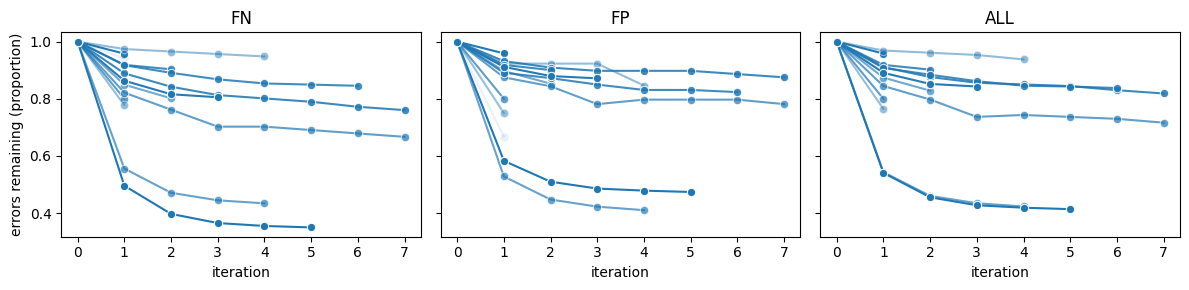

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# palette = sns.color_palette("blues", n_colors=all_metrics_info["ds_name"].nunique())
# palette = dict(zip(all_metrics_info["ds_name"].unique(), palette))

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, y) in enumerate(zip(axes, y_vars)):
    sns.lineplot(
        data=truncated_dfs[y],
        x="iteration",
        y=y,
        hue="ds_name",
        marker="o",
        # palette='blue',
        # color='blue',
        ax=ax,
    )
    ax.set_title(y.split('_')[0].upper())
    if i == 0:
        ax.set_ylabel("errors remaining (proportion)")
    for line, label in zip(ax.lines, ax.get_legend_handles_labels()[1]):
        if label in alphas:
            line.set_alpha(alphas[label])
            line.set_color(sns.color_palette()[0])
    ax.legend_.remove()
# handles, labels = axes[0].get_legend_handles_labels()
# for ax in axes:
#     ax.get_legend().remove()
# fig.legend(
#     handles,
#     labels,
#     loc="lower center",
#     ncol=4,
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.04)  # (x, y) in figure coords
# )
# fig.suptitle("Proportion of Edge Errors Remaining After Merge Resolution Iterations", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
alphas

{'BF-C2DL-HSC_01': np.float64(0.7089709409997662),
 'BF-C2DL-HSC_02': np.float64(0.9878400194319604),
 'BF-C2DL-MuSC_01': np.float64(0.6337171992795418),
 'BF-C2DL-MuSC_02': np.float64(0.6805176289818965),
 'Fluo-C3DL-MDA231_01': np.float64(0.1),
 'Fluo-N2DH-GOWT1_01': np.float64(0.46760897062405893),
 'Fluo-N2DH-GOWT1_02': np.float64(0.48712639800409563),
 'Fluo-N2DL-HeLa_01': np.float64(0.7076878994585297),
 'Fluo-N2DL-HeLa_02': np.float64(0.8650770128406625),
 'Fluo-N3DH-CE_01': np.float64(0.8561300023922618),
 'Fluo-N3DH-CE_02': np.float64(0.8472814683653384),
 'PhC-C2DL-PSC_01': np.float64(1.0),
 'PhC-C2DL-PSC_02': np.float64(0.97167317088823)}

In [33]:
total_det

array([ 8674, 64501,  5388,  7223,   351,  2054,  2287,  8602, 25378,
       23785, 22317, 71067, 56775])

In [ ]:
import json

with open('/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/n_new_merges_per_iter.json', 'r') as fp:
    n_new_merges_per_iter = json.load(fp)

In [65]:
n_new_merges_per_iter['Fluo-N3DH-CE_02']

{'0': {'n_new_merges': 11, 'total_merges': 14},
 '1': {'n_new_merges': 8, 'total_merges': 11},
 '2': {'n_new_merges': 5, 'total_merges': 8},
 '3': {'n_new_merges': 2, 'total_merges': 5},
 '4': {'n_new_merges': 2, 'total_merges': 5},
 '5': {'n_new_merges': 0, 'total_merges': 3},
 '6': {'n_new_merges': 0, 'total_merges': 0},
 '7': {'n_new_merges': 0, 'total_merges': 0}}

In [67]:
new_dict = {
    ds_name: {
        int(iter_key) + 1: metrics
        for iter_key, metrics in iter_dict.items()
    }
    for ds_name, iter_dict in n_new_merges_per_iter.items()
}

In [73]:
for ds, subdf in all_metrics_info.groupby('ds_name'):
    # get n_merges value from iteration 0
    base_val = subdf.loc[subdf['iteration'] == 0, 'n_merges'].iloc[0]

    # insert iteration 0 back into dict (keys should be strings)
    new_dict[ds][0] = {
        'n_new_merges': base_val,
        'total_merges': base_val
    }

In [75]:
all_metrics_info['n_new_merges'] = all_metrics_info.apply(
    lambda row: new_dict[row.ds_name][row.iteration]['n_new_merges'],
    axis=1
)

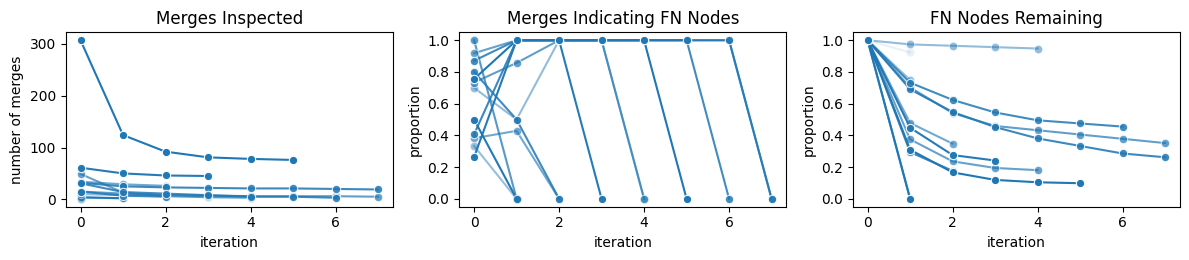

In [87]:
all_metrics_info.drop(columns=['n_merges', 'merges_to_introduced'], inplace=True, errors='ignore')
n_merges = all_merge_info.groupby(['ds_name', 'iteration']).size().reset_index(name='n_merges')
merges_to_introduced = all_merge_info[all_merge_info.parent_has_fn_succ].groupby(['ds_name', 'iteration']).size().reset_index(name='merges_to_introduced')
all_metrics_info = all_metrics_info.merge(n_merges, on=['ds_name', 'iteration'], how='left')
all_metrics_info = all_metrics_info.merge(merges_to_introduced, on=['ds_name', 'iteration'], how='left')
all_metrics_info['merges_to_fn_prop'] = all_metrics_info.merges_to_introduced / all_metrics_info.n_new_merges

# starting_col = all_metrics_info[all_metrics_info.iteration == 0][['ds_name', 'n_merges']]
# starting_col = dict(zip(starting_col['ds_name'], starting_col['n_merges']))
# all_metrics_info['n_merges_prop'] = all_metrics_info.apply(lambda row: row['n_merges'] / starting_col[row['ds_name']], axis=1)

for ds_name in all_metrics_info.ds_name.unique():
    sub = all_metrics_info[all_metrics_info.ds_name == ds_name].sort_values(by='iteration')
    nan_mask = sub['merges_to_fn_prop'].isna()
    fist_nan = nan_mask.idxmax()
    all_metrics_info.loc[fist_nan, 'merges_to_fn_prop'] = 0

y_vars = ['n_merges', 'merges_to_fn_prop', 'fn_nodes_prop']
truncated_dfs = {}
for y in y_vars:
    truncated_dfs[y] = truncate_when_constant(all_metrics_info, "ds_name", y)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3),
    sharex=True,
    # sharey=True
)
axes = axes.flatten()
for i, (ax, y) in enumerate(zip(axes, y_vars)):
    sns.lineplot(
        data=truncated_dfs[y],
        x="iteration",
        y=y,
        hue="ds_name",
        marker="o",
        # palette=palette,
        ax=ax,
    )
    ax.set_title(y)
    if i == 0:
        ax.set_title("Merges Inspected")
        ax.set_ylabel("number of merges")
    elif i == 1:
        ax.set_ylabel("proportion")
        ax.set_title("Merges Indicating FN Nodes")
    elif i == 2:
        ax.set_title("FN Nodes Remaining")
        ax.set_ylabel("proportion")
    for line, label in zip(ax.lines, ax.get_legend_handles_labels()[1]):
        if label in alphas:
            line.set_alpha(alphas[label])
            line.set_color(sns.color_palette()[0])
    ax.legend_.remove()
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     loc="lower center",
#     ncol=4,
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.3)  # (x, y) in figure coords
# )
fig.suptitle("")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

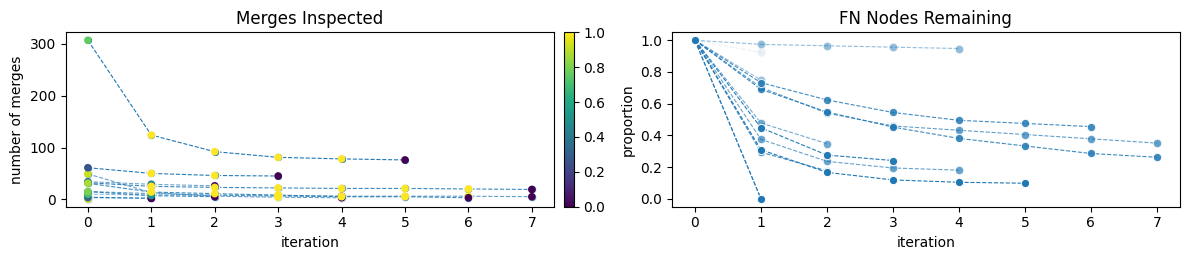

In [161]:
all_metrics_info.drop(columns=['n_merges', 'merges_to_introduced'], inplace=True, errors='ignore')
n_merges = all_merge_info.groupby(['ds_name', 'iteration']).size().reset_index(name='n_merges')
merges_to_introduced = all_merge_info[all_merge_info.parent_has_fn_succ].groupby(['ds_name', 'iteration']).size().reset_index(name='merges_to_introduced')
all_metrics_info = all_metrics_info.merge(n_merges, on=['ds_name', 'iteration'], how='left')
all_metrics_info = all_metrics_info.merge(merges_to_introduced, on=['ds_name', 'iteration'], how='left')
all_metrics_info['merges_to_fn_prop'] = all_metrics_info.merges_to_introduced / all_metrics_info.n_new_merges

# starting_col = all_metrics_info[all_metrics_info.iteration == 0][['ds_name', 'n_merges']]
# starting_col = dict(zip(starting_col['ds_name'], starting_col['n_merges']))
# all_metrics_info['n_merges_prop'] = all_metrics_info.apply(lambda row: row['n_merges'] / starting_col[row['ds_name']], axis=1)

for ds_name in all_metrics_info.ds_name.unique():
    sub = all_metrics_info[all_metrics_info.ds_name == ds_name].sort_values(by='iteration')
    nan_mask = sub['merges_to_fn_prop'].isna()
    fist_nan = nan_mask.idxmax()
    all_metrics_info.loc[fist_nan, 'merges_to_fn_prop'] = 0

# y_vars = ['n_merges', 'merges_to_fn_prop', 'fn_nodes_prop']
y_vars = ['n_merges', 'fn_nodes_prop']
truncated_dfs = {}
for y in y_vars:
    truncated_dfs[y] = truncate_when_constant(all_metrics_info, "ds_name", y)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 3),
    sharex=True,
    # sharey=True
)
axes = axes.flatten()

for i, (ax, y) in enumerate(zip(axes, y_vars)):
    sns.lineplot(
        data=truncated_dfs[y],
        x="iteration",
        y=y,
        hue="ds_name",
        marker="o",
        ax=ax,
        lw=0.8,
        linestyle='--'
    )
    for line, label in zip(ax.lines, ax.get_legend_handles_labels()[1]):
        if label in alphas:
            line.set_alpha(alphas[label])
            line.set_color(sns.color_palette()[0])
    if i == 0:
        df_sub = truncated_dfs[y].sort_values(["ds_name", "iteration"])
        norm = plt.Normalize(0, 1)
        cmap = plt.cm.viridis

        for name, subdf in df_sub.groupby("ds_name"):
            ax.scatter(
                subdf["iteration"],
                subdf[y],
                c=subdf["merges_to_fn_prop"],
                cmap=cmap,
                norm=norm,
                s=20,
                zorder=2
            )


    # titles and labels
    if i == 0:
        ax.set_title("Merges Inspected")
        ax.set_ylabel("number of merges")
    # elif i == 1:
    #     ax.set_title("Merges Indicating FN Nodes")
    #     ax.set_ylabel("proportion")
    else:
        ax.set_title("FN Nodes Remaining")
        ax.set_ylabel("proportion")
    # remove normal legend
    if ax.get_legend() is not None:
        ax.legend_.remove()
fig.suptitle("")
norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

pos0 = axes[0].get_position()
pos1 = axes[1].get_position()

# Compute colorbar axis position
cbar_left = pos0.x1 + (pos1.x0 - pos0.x1) * 0.5
cbar_width = 0.010

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(axes[0])
cax = divider.new_horizontal(size="2%", pad=0.1)
fig.add_axes(cax)
fig.colorbar(
    sm,
    cax=cax,
    fraction=0.02,
    pad=0.04,
    aspect=20
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.tight_layout()
plt.show()

In [169]:
total_merges_inspected = truncated_dfs['n_merges'].groupby('ds_name').n_merges.sum().reset_index()

In [170]:
total_introduced = truncated_dfs['n_merges'].groupby('ds_name').introduced.sum().reset_index()

In [172]:
total_merges_inspected = total_merges_inspected.merge(total_introduced, on='ds_name')

In [174]:
total_merges_inspected['found_per_inspected'] = total_merges_inspected.introduced / total_merges_inspected.n_merges

In [176]:
total_merges_inspected.found_per_inspected.describe()

count    13.000000
mean      0.467719
std       0.312118
min       0.108911
25%       0.200000
50%       0.380952
75%       0.714286
max       1.000000
Name: found_per_inspected, dtype: float64

In [ ]:
edges_per_introduced = all_metrics_info.groupby('ds_name').corrections_per_introduced.mean().reset_index()

In [106]:
edges_per_introduced['total_det'] = 0
for ds_name in edges_per_introduced.ds_name:
    total_det_ds = ds_summary.loc[ds_summary['ds_name'] == ds_name, 'total_det'].values[0]
    edges_per_introduced.loc[edges_per_introduced['ds_name'] == ds_name, 'total_det'] = total_det_ds

In [108]:
edges_per_introduced['log_det'] = np.log(edges_per_introduced['total_det'])

In [159]:
len(truncated_dfs['all_edge_errors_prop'].groupby('ds_name').introduced.sum())

13

In [160]:
edges_per_introduced

,ds_name,corrections_per_introduced,total_det,log_det
0,BF-C2DL-HSC_01,4.000000,8674,9.068085
1,BF-C2DL-HSC_02,3.000000,64501,11.074436
2,BF-C2DL-MuSC_01,3.375000,5388,8.591930
3,BF-C2DL-MuSC_02,3.363889,7223,8.885026
4,Fluo-C3DL-MDA231_01,2.000000,351,5.860786
5,Fluo-N2DH-GOWT1_01,4.000000,2054,7.627544
6,Fluo-N2DH-GOWT1_02,1.333333,2287,7.734996
7,Fluo-N2DL-HeLa_01,1.608225,8602,9.059750
8,Fluo-N2DL-HeLa_02,2.043040,25378,10.141638
9,Fluo-N3DH-CE_01,3.625000,23785,10.076810


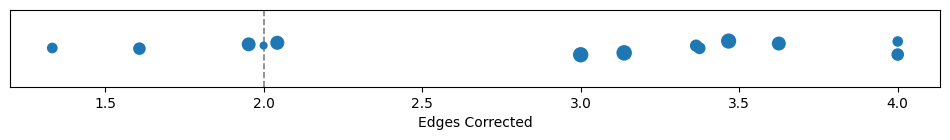

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 1))
sns.stripplot(x=edges_per_introduced["corrections_per_introduced"], size=edges_per_introduced['log_det'])
plt.axvline(2, color="grey", linestyle="--", linewidth=1.2)

plt.yticks([])                 # remove y-axis ticks
plt.xlabel("Edges Corrected")
# plt.title("Edges Corrected per Introduced FN Node")

plt.show()

13

## Exploring kit-ge solving

In [ ]:
# let's see the original node counts for each dataset

import json


original_root_pth = '/home/ddon0001/PhD/experiments/scaled/no_div_constraint_err_seg'
ds_summary = pd.read_csv(f'{original_root_pth}/summary.csv')

ds_names = []
fp_nodes = []
fn_nodes = []
ns_nodes = []
for row in ds_summary.itertuples():
    ds = row.ds_name
    metrics_pth = f'{original_root_pth}/{ds}/metrics.json'
    with open(metrics_pth, 'r') as f:
        metrics = json.load(f)
    ds_names.append(ds)
    fp_nodes.append(metrics['fp_nodes'])
    fn_nodes.append(metrics['fn_nodes'])
    ns_nodes.append(metrics['ns_nodes'])

original_node_counts = pd.DataFrame({
    'ds_name': ds_names,
    'og_fp_nodes': fp_nodes,
    'og_fn_nodes': fn_nodes,
    'og_ns_nodes': ns_nodes,
})

kit_root = '/home/ddon0001/PhD/experiments/kit-ge'
kit_fp_nodes = []
kit_fn_nodes = []
kit_ns_nodes = []
for row in ds_summary.itertuples():
    ds = row.ds_name
    ds, seq = ds.split('_')
    metrics_pth = f'{kit_root}/{ds}/{seq}_matched.zarr/traccuracy-results.json'
    with open(metrics_pth, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
        kit_fp_nodes.append(metrics['fp_nodes'])
        kit_fn_nodes.append(metrics['fn_nodes'])
        kit_ns_nodes.append(metrics['ns_nodes'])
original_node_counts['kit_fp_nodes'] = kit_fp_nodes
original_node_counts['kit_fn_nodes'] = kit_fn_nodes
original_node_counts['kit_ns_nodes'] = kit_ns_nodes

original_node_counts[['ds_name', 'og_fn_nodes', 'kit_fn_nodes', 'og_fp_nodes', 'kit_fp_nodes', 'og_ns_nodes', 'kit_ns_nodes']].sort_values(by='og_fn_nodes', ascending=False)

In [89]:
# import json
# import os
# import pandas as pd

# pre_introduce_root = '/home/ddon0001/PhD/experiments/scaled/no_div_constraint_err_seg'
# post_introduce_root = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/merge_introduced_solved'
# ds_summary_path = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/merge_introduced_solved/summary.csv'
# ds_summary = pd.read_csv(ds_summary_path)

In [90]:
# pre_introduce_ds_name = []
# pre_introduce_tra = []
# pre_introduce_fp_nodes = []
# pre_introduce_fn_nodes = []
# pre_introduce_ns_nodes = []
# pre_introduce_fp_edges = []
# pre_introduce_fn_edges = []
# pre_introduce_ws_edges = []

# for ds_row in ds_summary.itertuples():
#     name = ds_row.ds_name
#     metrics_path = os.path.join(pre_introduce_root, name, 'metrics.json')
#     with open(metrics_path, 'r') as f:
#         metrics = json.load(f)
    
#     pre_introduce_ds_name.append(name)
#     pre_introduce_tra.append(metrics['TRA'])
#     pre_introduce_fp_nodes.append(metrics['fp_nodes'])
#     pre_introduce_fn_nodes.append(metrics['fn_nodes'])
#     pre_introduce_ns_nodes.append(metrics['ns_nodes'])
#     pre_introduce_fp_edges.append(metrics['fp_edges'])
#     pre_introduce_fn_edges.append(metrics['fn_edges'])
#     pre_introduce_ws_edges.append(metrics['ws_edges'])

# pre_introduce_df = pd.DataFrame({
#     'ds_name': pre_introduce_ds_name,
#     'TRA': pre_introduce_tra,
#     'fp_nodes': pre_introduce_fp_nodes,
#     'fn_nodes': pre_introduce_fn_nodes,
#     'ns_nodes': pre_introduce_ns_nodes,
#     'fp_edges': pre_introduce_fp_edges,
#     'fn_edges': pre_introduce_fn_edges,
#     'ws_edges': pre_introduce_ws_edges
# })
# pre_introduce_df['iteration'] = 0


In [93]:
# post_introduce_tra = []
# post_introduce_fp_nodes = []
# post_introduce_fn_nodes = []
# post_introduce_ns_nodes = []
# post_introduce_fp_edges = []
# post_introduce_fn_edges = []
# post_introduce_ws_edges = []

# last_iter_info = {}
# for ds_row in ds_summary.itertuples():
#     name = ds_row.ds_name
#     metrics_path = os.path.join(post_introduce_root, name, 'matched_solution.zarr/traccuracy-results.json')
#     with open(metrics_path, 'r') as f:
#         metrics = json.load(f)['traccuracy'][0]['results']
    
#     post_introduce_tra.append(metrics['TRA'])
#     post_introduce_fp_nodes.append(metrics['fp_nodes'])
#     post_introduce_fn_nodes.append(metrics['fn_nodes'])
#     post_introduce_ns_nodes.append(metrics['ns_nodes'])
#     post_introduce_fp_edges.append(metrics['fp_edges'])
#     post_introduce_fn_edges.append(metrics['fn_edges'])
#     post_introduce_ws_edges.append(metrics['ws_edges'])
#     last_iter_info[name] = metrics
# post_introduce_df = pd.DataFrame({
#     'ds_name': pre_introduce_ds_name,
#     'TRA': post_introduce_tra,
#     'fp_nodes': post_introduce_fp_nodes,
#     'fn_nodes': post_introduce_fn_nodes,
#     'ns_nodes': post_introduce_ns_nodes,
#     'fp_edges': post_introduce_fp_edges,
#     'fn_edges': post_introduce_fn_edges,
#     'ws_edges': post_introduce_ws_edges
# })
# post_introduce_df['iteration'] = 1


In [94]:
# iter_root = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/'
# ds_names = []
# iteration_info = []
# tra_info = []
# fp_nodes_info = []
# fn_nodes_info = []
# ns_nodes_info = []
# fp_edges_info = []
# fn_edges_info = []
# ws_edges_info = []
# for i in range(1, 8):
#     iter_solved_root = os.path.join(iter_root, f'merge_introduced_solved_{i}')
#     for ds_row in ds_summary.itertuples():
#         name = ds_row.ds_name
#         ds_names.append(name)
#         iteration_info.append(i+1)
#         metrics_path = os.path.join(iter_solved_root, name, 'matched_solution.zarr/traccuracy-results.json')
#         if not os.path.exists(metrics_path):
#             last_info = last_iter_info[name]
#             tra_info.append(last_info['TRA'])
#             fp_nodes_info.append(last_info['fp_nodes'])
#             fn_nodes_info.append(last_info['fn_nodes'])
#             ns_nodes_info.append(last_info['ns_nodes'])
#             fp_edges_info.append(last_info['fp_edges'])
#             fn_edges_info.append(last_info['fn_edges'])
#             ws_edges_info.append(last_info['ws_edges'])
#         else:
#             with open(metrics_path, 'r') as f:
#                 metrics = json.load(f)['traccuracy'][0]['results']
#             tra_info.append(metrics['TRA'])
#             fp_nodes_info.append(metrics['fp_nodes'])
#             fn_nodes_info.append(metrics['fn_nodes'])
#             ns_nodes_info.append(metrics['ns_nodes'])
#             fp_edges_info.append(metrics['fp_edges'])
#             fn_edges_info.append(metrics['fn_edges'])
#             ws_edges_info.append(metrics['ws_edges'])
#             last_iter_info[name] = metrics
# iter_df = pd.DataFrame({
#     'ds_name': ds_names,
#     'TRA': tra_info,
#     'fp_nodes': fp_nodes_info,
#     'fn_nodes': fn_nodes_info,
#     'ns_nodes': ns_nodes_info,
#     'fp_edges': fp_edges_info,
#     'fn_edges': fn_edges_info,
#     'ws_edges': ws_edges_info,
#     'iteration': iteration_info,
# })
# all_df = pd.concat([pre_introduce_df, post_introduce_df, iter_df], ignore_index=True)

In [96]:
# merge_info_0 = pd.read_csv('/home/ddon0001/PhD/experiments/scaled/no_div_constraint_err_seg/merge_info.csv')
# merge_info_0['iteration'] = 0
# merge_info_1 = pd.read_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/merge_introduced_solved/merge_info.csv')
# merge_info_1['iteration'] = 1

# merge_infos = []
# for i in range(1, 8):
#     iter_merge_info = pd.read_csv(f'/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/merge_introduced_solved_{i}/merge_info.csv')
#     iter_merge_info['iteration'] = i+1
#     problem_row_1 = iter_merge_info[(iter_merge_info.ds_name == 'Fluo-N2DH-GOWT1_02') & (iter_merge_info.fn_succ == 2455)]
#     problem_row_2 = iter_merge_info[(iter_merge_info.ds_name == 'BF-C2DL-MuSC_01') & (iter_merge_info.fn_succ == 4328)]
#     merge_infos.append(iter_merge_info)
# all_merge_info = pd.concat([merge_info_0, merge_info_1] + merge_infos, ignore_index=True)
# problem_rows = all_merge_info[(all_merge_info.ds_name == 'BF-C2DL-MuSC_01') & (all_merge_info.fn_succ == 4328)]
# problem_rows_2 = all_merge_info[(all_merge_info.ds_name == 'Fluo-N2DH-GOWT1_02') & (all_merge_info.fn_succ == 2455)]
# all_merge_info.loc[problem_rows.index, 'fn_succ'] = -1
# all_merge_info.loc[problem_rows.index, 'parent_has_fn_succ'] = False
# all_merge_info.loc[problem_rows_2.index, 'fn_succ'] = -1
# all_merge_info.loc[problem_rows_2.index, 'parent_has_fn_succ'] = False

In [102]:
# all_df.to_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/all_iterations_metrics.csv', index=False)
# all_merge_info.to_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/merge_resolution/all_iterations_merge_info.csv', index=False)